# 🫁 Liver Disease Prediction: ML for Hepatology Screening

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **Dept of Health** — National Hepatitis B/C Strategy, liver disease prevention
- **AIHW** — Liver disease surveillance, alcohol-related harm reporting
- **Medicare** — Liver function test rebates, hepatology referral pathways
- **PBS** — Antiviral therapy access, alcohol dependence medications
- **Liver Foundation** — Awareness, screening program support

Dataset: Indian Liver Patient — 583 samples, 10 features, binary. Mostly numeric.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
print("READY")

READY


In [2]:
dp=None
for r,d,files in os.walk('/kaggle/input'):
    for f in files:
        fp=os.path.join(r,f);print(f"  {fp}")
        if f.endswith('.csv') and dp is None: dp=fp
if dp is None: raise FileNotFoundError("No CSV")
df=pd.read_csv(dp,encoding='latin-1')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:30s} | {str(df[col].dtype):8s} | uniq={df[col].nunique():5d} | nulls={df[col].isnull().sum()}")
df.head()

  /kaggle/input/datasets/organizations/uciml/indian-liver-patient-records/indian_liver_patient.csv
Loaded: 583 x 11
   0. Age                            | int64    | uniq=   72 | nulls=0
   1. Gender                         | object   | uniq=    2 | nulls=0
   2. Total_Bilirubin                | float64  | uniq=  113 | nulls=0
   3. Direct_Bilirubin               | float64  | uniq=   80 | nulls=0
   4. Alkaline_Phosphotase           | int64    | uniq=  263 | nulls=0
   5. Alamine_Aminotransferase       | int64    | uniq=  152 | nulls=0
   6. Aspartate_Aminotransferase     | int64    | uniq=  177 | nulls=0
   7. Total_Protiens                 | float64  | uniq=   58 | nulls=0
   8. Albumin                        | float64  | uniq=   40 | nulls=0
   9. Albumin_and_Globulin_Ratio     | float64  | uniq=   69 | nulls=4
  10. Dataset                        | int64    | uniq=    2 | nulls=0


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## 2. Target

In [3]:
tc=None
for x in ['Dataset','dataset','is_patient','target','Target','class','Class','Selector','Result']:
    if x in df.columns: tc=x;break
if tc is None:
    for x in df.columns:
        if df[x].nunique()==2 and df[x].dtype in ['int64','float64']: tc=x;break
if tc is None: tc=df.columns[-1]
df=df.dropna(subset=[tc])
# Dataset column: 1=liver patient, 2=not -> remap to 1=patient, 0=not
if df[tc].nunique()==2:
    vals=sorted(df[tc].unique())
    if vals==[1,2]: df[tc]=df[tc].map({1:1,2:0})
df[tc]=df[tc].astype(int)
print(f"Target: '{tc}'");print(df[tc].value_counts().sort_index())
assert df[tc].nunique()>=2

Target: 'Dataset'
Dataset
0    167
1    416
Name: count, dtype: int64


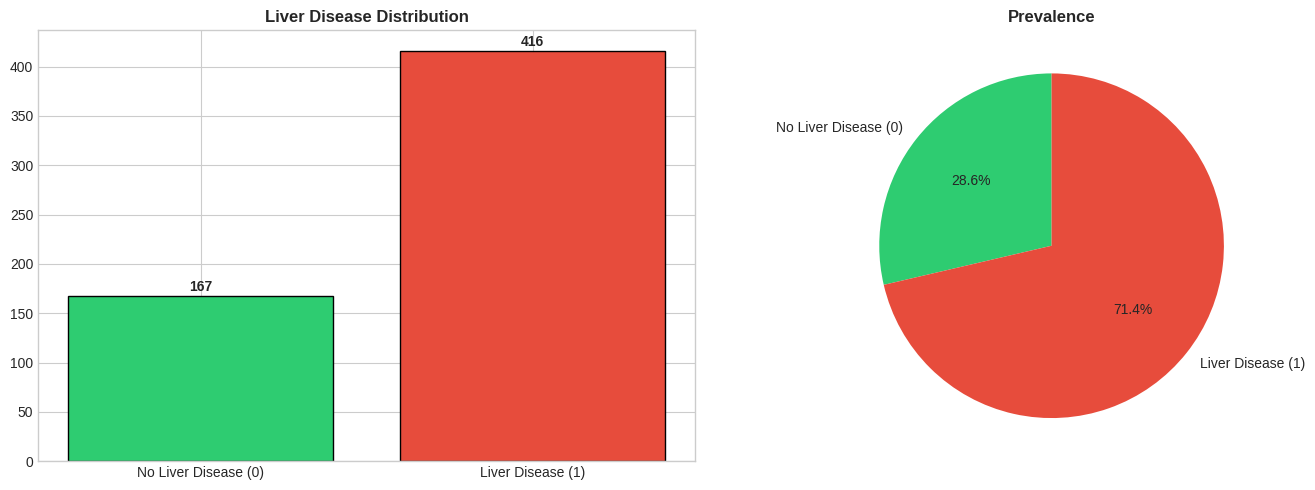

AU: Liver disease affects ~6M Australians. Alcohol and hepatitis are leading causes.


In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();labels=['No Liver Disease (0)','Liver Disease (1)'];colors=['#2ecc71','#e74c3c']
axes[0].bar(range(2),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(2));axes[0].set_xticklabels(labels)
axes[0].set_title('Liver Disease Distribution',fontweight='bold')
for i,v in enumerate(vc.values): axes[0].text(i,v+5,str(v),ha='center',fontweight='bold')
axes[1].pie(vc.values,labels=labels,autopct='%1.1f%%',colors=colors,startangle=90)
axes[1].set_title('Prevalence',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: Liver disease affects ~6M Australians. Alcohol and hepatitis are leading causes.")

## 3. EDA

Numeric(9): ['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']


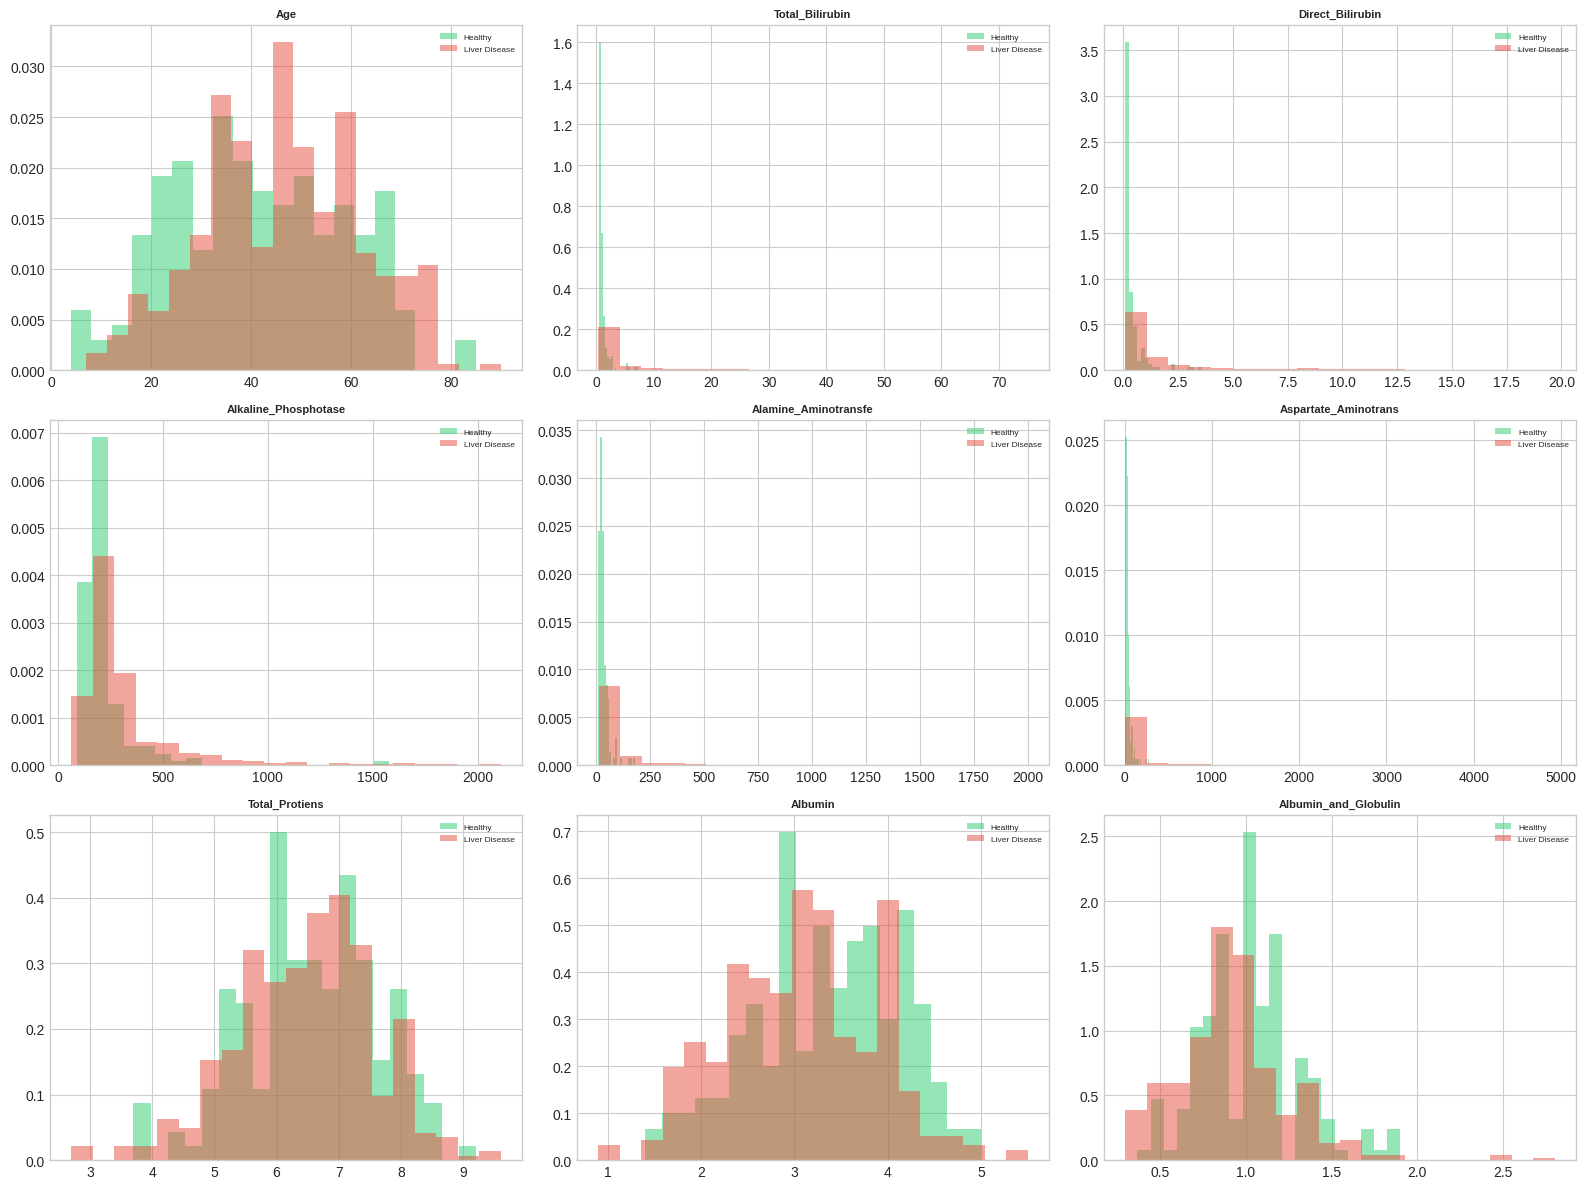

In [5]:
nums=[c for c in df.select_dtypes(include=[np.number]).columns if c!=tc]
print(f"Numeric({len(nums)}): {nums}")
fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
for i,col in enumerate(nums[:9]):
    for l,clr,n in zip([0,1],colors,['Healthy','Liver Disease']):
        s=df[df[tc]==l][col].dropna()
        if len(s)>0: axes[i].hist(s,bins=20,alpha=0.5,label=n,density=True,color=clr)
    axes[i].set_title(col[:20],fontsize=8,fontweight='bold');axes[i].legend(fontsize=6)
for j in range(i+1,len(axes)):axes[j].set_visible(False)
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

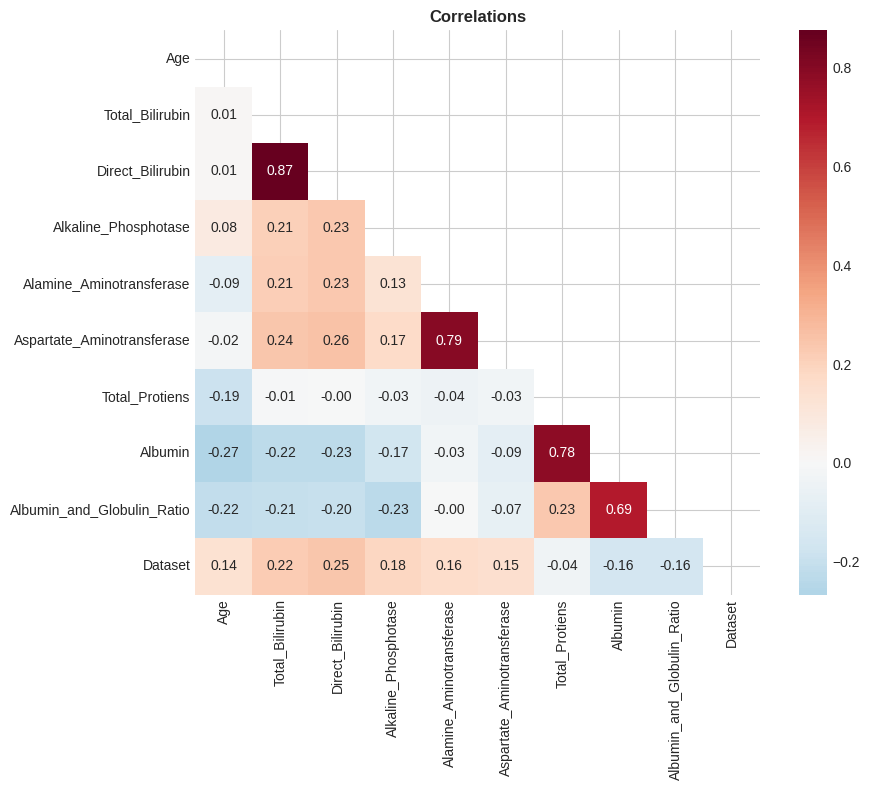

In [6]:
corr=df[nums+[tc]].corr()
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax)
ax.set_title('Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [7]:
le_d={}
for col in df.select_dtypes('object').columns:
    if col!=tc:
        le=LabelEncoder();df[col]=le.fit_transform(df[col].fillna('_NA_').astype(str));le_d[col]=le
        print(f"  Encoded '{col}': {len(le.classes_)}")
nums2=[c for c in df.select_dtypes(include=[np.number]).columns if c!=tc]
X=df[nums2].copy();y=df[tc].values;X=X.fillna(X.median())
print(f"X: {X.shape}")

  Encoded 'Gender': 2
X: (583, 10)


## 5. Training

In [8]:
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fu=[],[],[];fp=np.zeros(len(y),dtype=int);fpr=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;fpr[vi]=yb
        a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp);u=roc_auc_score(y[vi],yb)
        fa.append(a);ff.append(f);fu.append(u)
        print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} AUC={u:.4f}")
    el=time.time()-t0
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'time':el,'preds':fp,'proba':fpr}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f} T={el:.1f}s")


LogReg
  Fold1: Acc=0.7333 F1=0.8354 AUC=0.7780
  Fold2: Acc=0.7062 F1=0.8106 AUC=0.7364
  Fold3: Acc=0.6907 F1=0.8000 AUC=0.7435
  AVG: Acc=0.7101 F1=0.8154 AUC=0.7527 T=0.3s

RF
  Fold1: Acc=0.7179 F1=0.8148 AUC=0.7871
  Fold2: Acc=0.6856 F1=0.7946 AUC=0.7232
  Fold3: Acc=0.7062 F1=0.8055 AUC=0.7560
  AVG: Acc=0.7032 F1=0.8050 AUC=0.7555 T=1.0s

XGB
  Fold1: Acc=0.6872 F1=0.7860 AUC=0.7205
  Fold2: Acc=0.6598 F1=0.7708 AUC=0.6942
  Fold3: Acc=0.7010 F1=0.7943 AUC=0.7312
  AVG: Acc=0.6827 F1=0.7837 AUC=0.7153 T=0.2s

LGBM
  Fold1: Acc=0.6923 F1=0.7959 AUC=0.7400
  Fold2: Acc=0.6856 F1=0.7875 AUC=0.7094
  Fold3: Acc=0.7062 F1=0.8014 AUC=0.7642
  AVG: Acc=0.6947 F1=0.7949 AUC=0.7379 T=0.2s


## 6. Comparison

In [9]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'AUC':f"{v['auc']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['auc']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*70);print(sdf[['Model','Acc','F1','AUC','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc     F1    AUC Time
    RF 0.7032 0.8050 0.7555 1.0s
LogReg 0.7101 0.8154 0.7527 0.3s
  LGBM 0.6947 0.7949 0.7379 0.2s
   XGB 0.6827 0.7837 0.7153 0.2s

Best: RF


## 7. Error Analysis

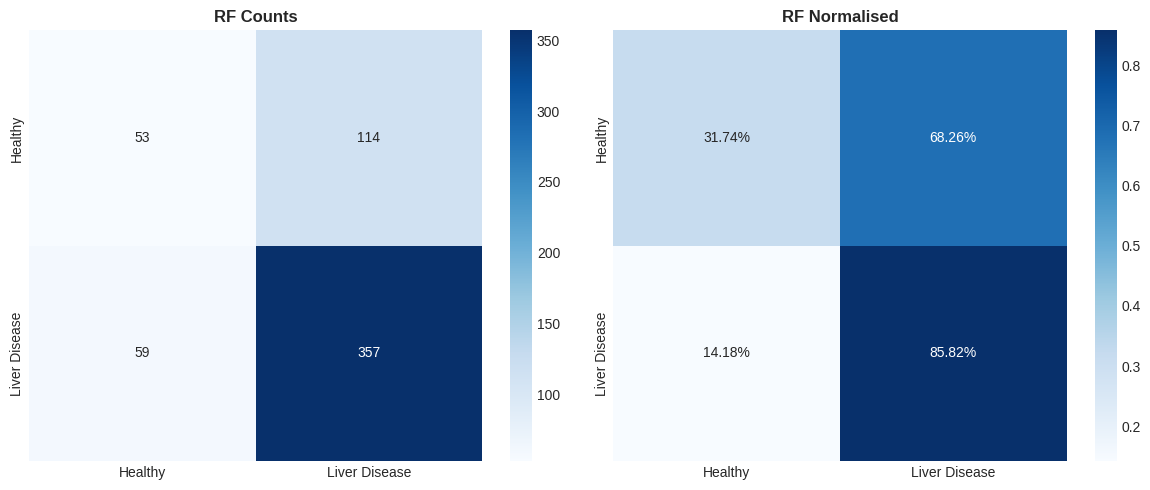

               precision    recall  f1-score   support

      Healthy       0.47      0.32      0.38       167
Liver Disease       0.76      0.86      0.80       416

     accuracy                           0.70       583
    macro avg       0.62      0.59      0.59       583
 weighted avg       0.68      0.70      0.68       583



In [10]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Healthy','Liver Disease'],yticklabels=['Healthy','Liver Disease'],ax=axes[0])
axes[0].set_title(f'{best} Counts',fontweight='bold')
cm_n=cm.astype(float)/cm.sum(axis=1,keepdims=True)
sns.heatmap(cm_n,annot=True,fmt='.2%',cmap='Blues',xticklabels=['Healthy','Liver Disease'],yticklabels=['Healthy','Liver Disease'],ax=axes[1])
axes[1].set_title(f'{best} Normalised',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=['Healthy','Liver Disease']))

## 8. Feature Importance

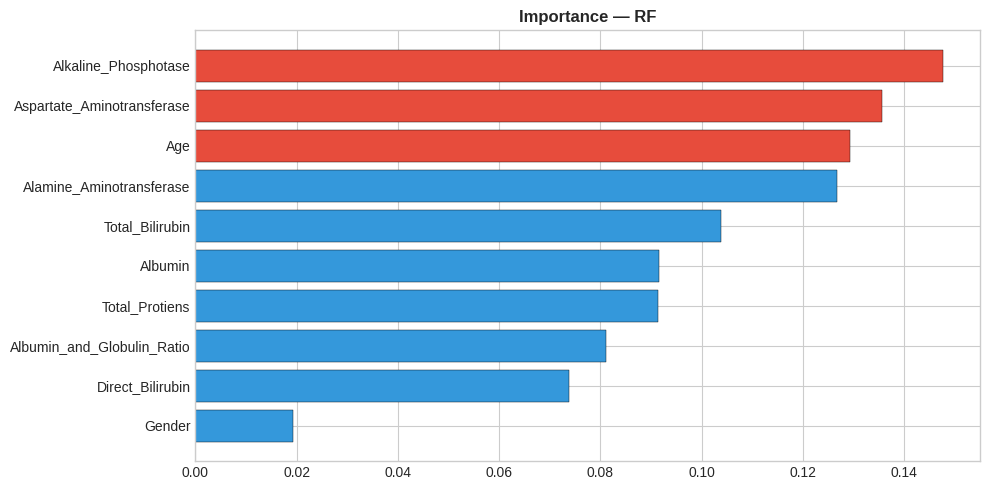

TOP 5
  Alkaline_Phosphotase           0.1476
  Aspartate_Aminotransferase     0.1356
  Age                            0.1294
  Alamine_Aminotransferase       0.1267
  Total_Bilirubin                0.1037


In [11]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m:results[m]['auc']);fm=type(models[bt])(**models[bt].get_params());fm.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(5,len(fi)*0.5)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#e74c3c' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    print("TOP 5");print("="*40)
    for _,r in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r['Feature']:30s} {r['Imp']:.4f}")

## 9. Deployment

In [12]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}");print(f"  AUC:   {br['auc']:.4f}");print(f"  F1:    {br['f1']:.4f}")
print(f"  Time:  {br['time']:.1f}s");print(f"  Feats: {X.shape[1]}");print(f"  Rows:  {len(y):,}");print("="*60)
checks={'AUC>0.60':br['auc']>0.60,'F1>0.50':br['f1']>0.50,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model: RF
  AUC:   0.7555
  F1:    0.8050
  Time:  1.0s
  Feats: 10
  Rows:  583

CHECKLIST
----------------------------------------
  [pass] AUC>0.60
  [pass] F1>0.50
  [pass] Time<60s
  [pass] CV
----------------------------------------
  APPROVED


In [13]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: Pathology LIMS (LFTs, albumin, bilirubin) -> Fabric Lakehouse
2. MODEL: Real-time at pathology result, GP clinical decision support
3. INTEGRATE: GP systems, Medicare pathology, hepatology referral
4. GOVERN: TGA SaMD, RACGP guidelines, patient consent
5. MONITOR: Validate vs hepatologist diagnosis, retrain annually
""")


PRODUCTION ARCHITECTURE
1. DATA: Pathology LIMS (LFTs, albumin, bilirubin) -> Fabric Lakehouse
2. MODEL: Real-time at pathology result, GP clinical decision support
3. INTEGRATE: GP systems, Medicare pathology, hepatology referral
4. GOVERN: TGA SaMD, RACGP guidelines, patient consent
5. MONITOR: Validate vs hepatologist diagnosis, retrain annually

